# Free Space Path Loss (FSPL)

Model the signal loss as the distance increases by modelling it using FSPL equations.

$$
FSPL = 20log(d) + 20log(f) - 147.55 - G_t - G_r
$$

Where:
- FSPL is in dB
- $d$ is the distance from the transmitter
- $f$ is the frequency of the wave, so 24MHz
- $G_t$ is the transmitter's gain
- $G_r$ is the receiver's gain. It's assumed this is 1 as the antenna is isotropic?

References:
- https://en.wikipedia.org/wiki/Free-space_path_loss
- https://www.pasternack.com/t-calculator-fspl.aspx
- https://www.bdamax.com/blog/db-vs-dbm-whats-the-real-difference/

In [1]:
import math

def signal_loss(distance :float, frequency = 2_400_000_000, transmitter_gain = 14, receiver_gain = 1):
    return 20 * math.log10(distance) + 20 * math.log10(frequency) - 147.55  - transmitter_gain - receiver_gain

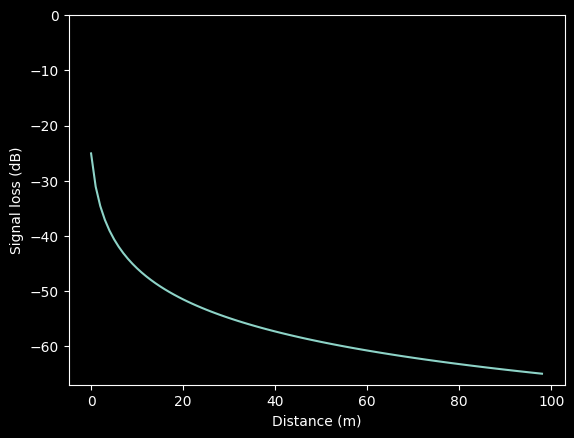

In [2]:
import matplotlib.pyplot as plt

points = []

for x in range (1, 100, 1):
    points.append(signal_loss(x) * - 1)

plt.plot(points)
plt.ylim(ymax=0)
plt.xlabel("Distance (m)")
plt.ylabel("Signal loss (dB)")
plt.show()

## Estimated vs Received Signal Strength

Model what the FSPL equation estimates the RSS should be at a given distance from the transmitter, and compare this to the actual signal strength received by the tag.

Looks at `/March 26 2025 Field Trial/straightpath5/` experiment, where the device moved ~181m.

Known inaccuracies:
- Real `transmitter_power` is unknown, but -6dBm fits the data
- The tag may not have travelled at a constant velocity in a straight line
- The entire dataset is used and it's assumed there are no pauses at the start/end and the tag doesn't retrace its steps

### Conclusion

The attenuation of the BLE signal mildly resemble the model of signal loss using FSPL equations.

### Transmitter E

First, look at transmitter A which is right by the start of the straight path

Standardising angles and times (shifting by 0.00 degrees)


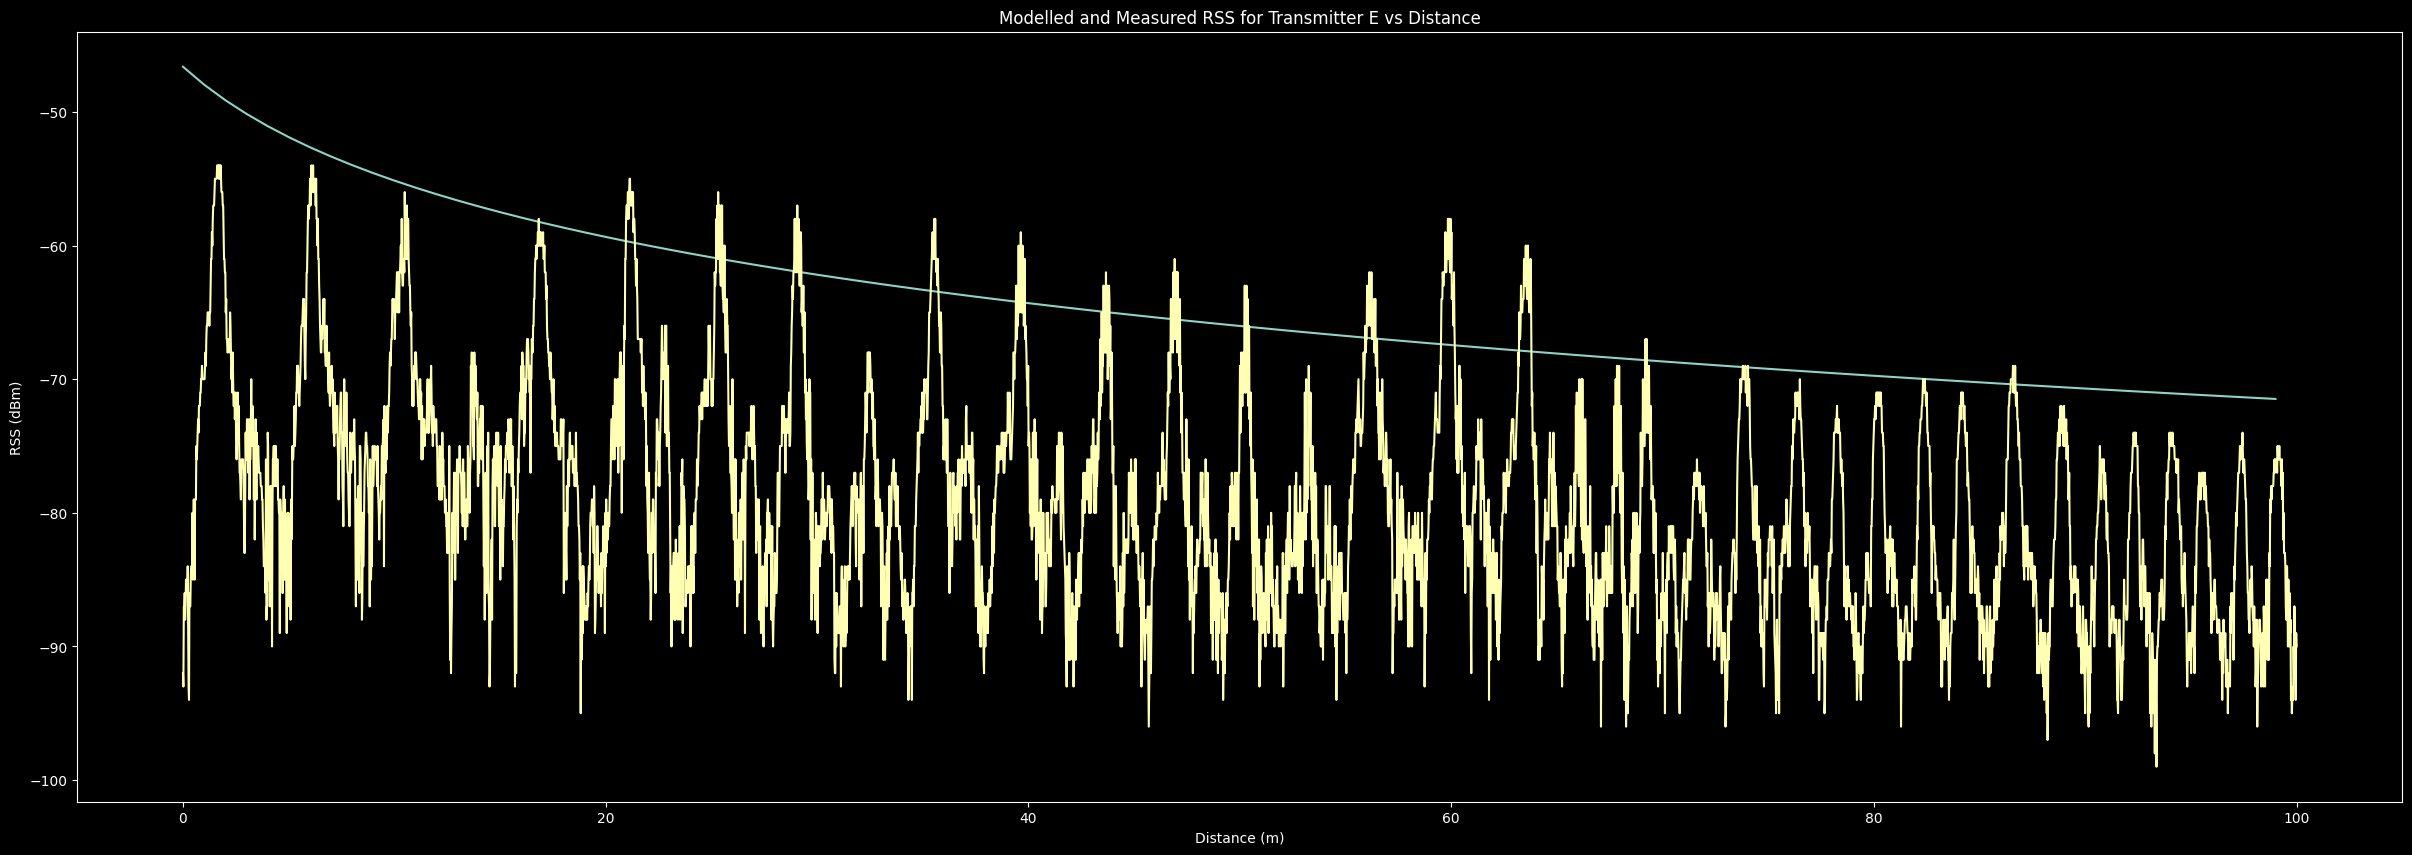

In [3]:
from BLEanalysis.signals import Signals
import numpy as np

transmitter_power = -6 # dBm
dist_travelled = 100 # m
num_data_points = 5000

# generate the model received signal strength
model_points = []

for x in range (6, dist_travelled + 6, 1):
    model_points.append(-1 * signal_loss(x) + transmitter_power)

# plot actual RSS from the tag
straight5_data = Signals("../../bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", ['e'],filetype='log',angleOffset=0).data[110:num_data_points,0]
tag_x = np.linspace(0, dist_travelled, num_data_points - 110)

# draw the graphs
plt.figure(figsize=(30,10))
plt.plot(model_points)
plt.plot(tag_x, straight5_data)
plt.ylabel("RSS (dBm)")
plt.xlabel("Distance (m)")
plt.title("Modelled and Measured RSS for Transmitter E vs Distance")
plt.show()

### Transmitter B

Examine the predicted and real RSS as the tag approaches transmitter B. It has been estimated the tag started 137m away and finished 37m away from the transmitter. Again, these measurements have been chosen on what fits the data.

Standardising angles and times (shifting by 0.00 degrees)


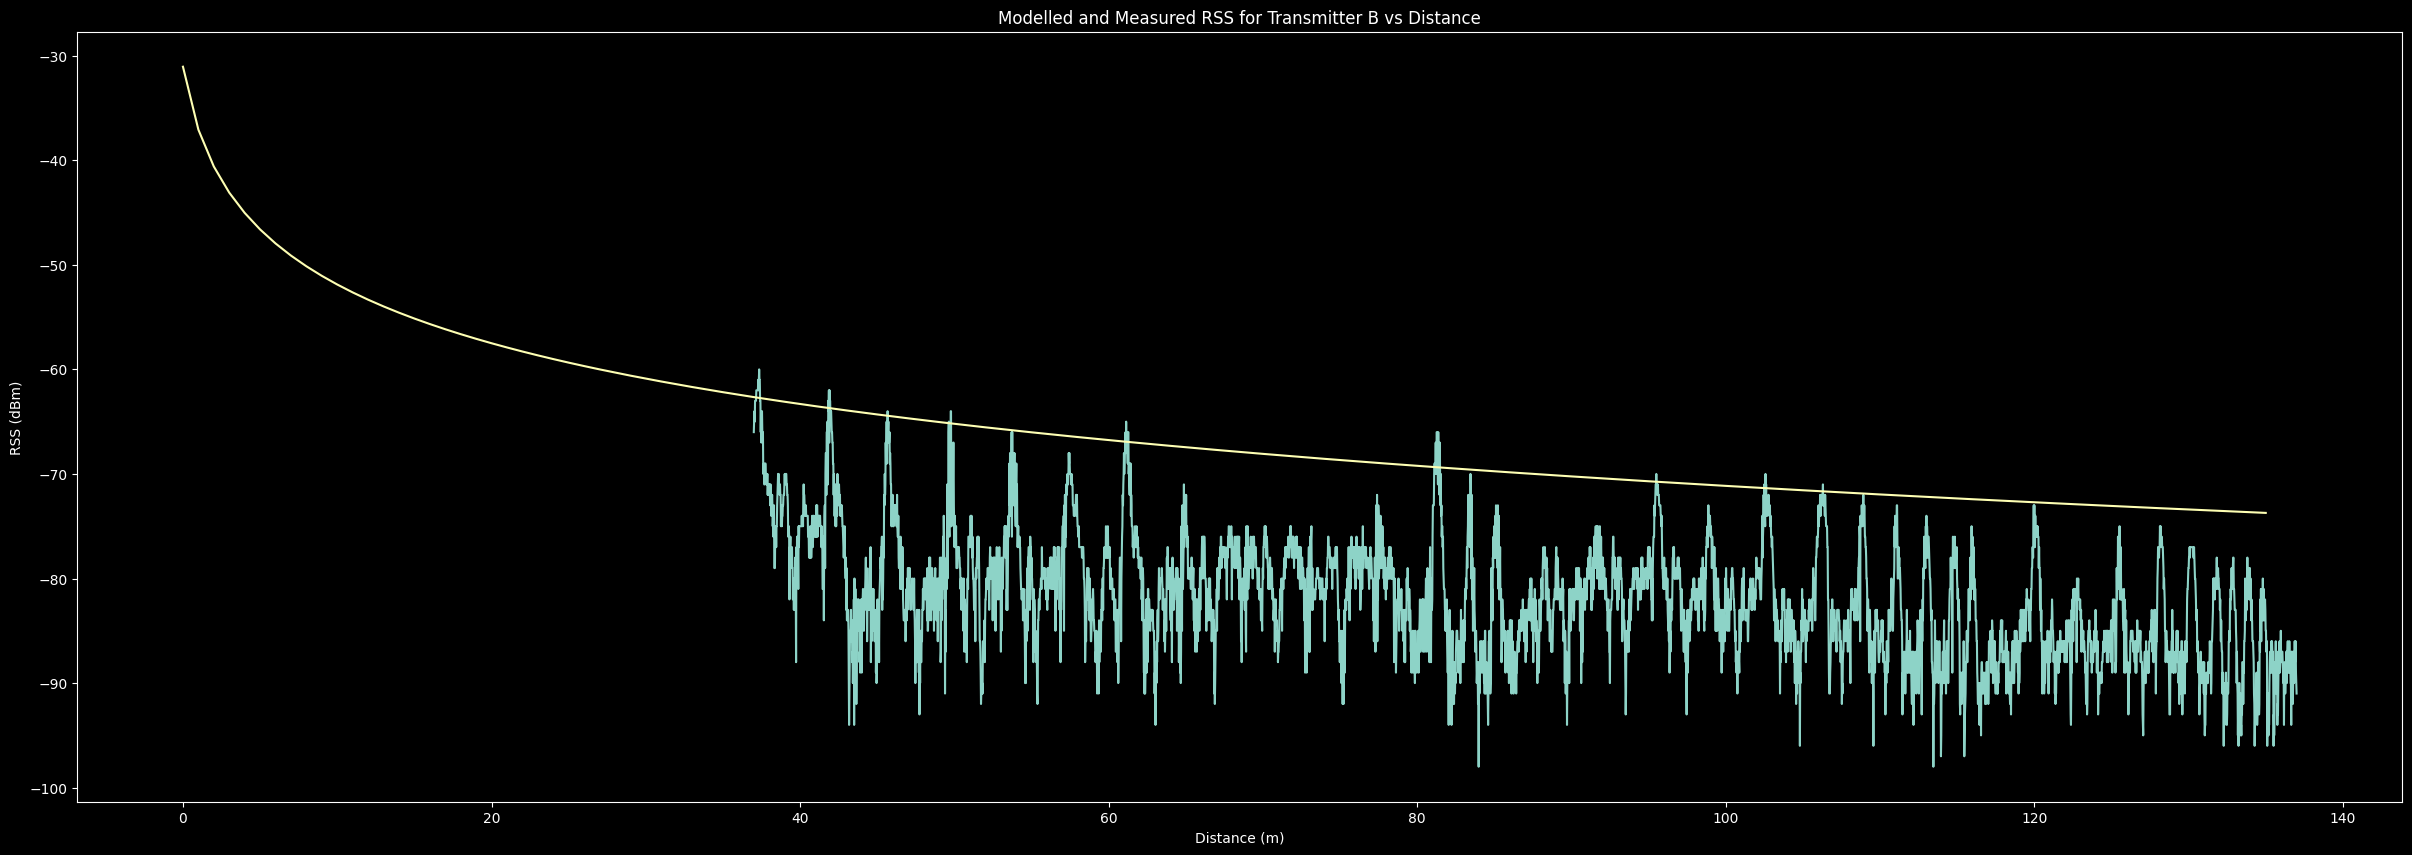

In [4]:
dist_remaining_to_b = 37 # m

straight5_data_b = np.flip(Signals("../../bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", ['b'],filetype='log',angleOffset=0).data[110:num_data_points,0])
tag_x = np.linspace(dist_remaining_to_b, dist_travelled + dist_remaining_to_b, num_data_points - 110)

b_model_points = []

for x in range (1, dist_travelled + dist_remaining_to_b, 1):
    b_model_points.append(-1 * signal_loss(x) + transmitter_power)

plt.figure(figsize=(30,10))
plt.plot(tag_x, straight5_data_b)
plt.plot(b_model_points)
plt.ylabel("RSS (dBm)")
plt.xlabel("Distance (m)")
plt.title("Modelled and Measured RSS for Transmitter B vs Distance")
plt.show()

## Use GPS to Determine Tag Location

By cross-referencing the normalised time stamps of the GPS receiver and tag, plot the RSS of the packets when the tag is a given distance away from the transmitter. The tag starts at transmitter E and finishes at transmitter B. This is more accurate as the exact position of the tag can be found, rather than guessing its position from the path inference.

### Overview of GPS and Log Data

Analyse aspects of the GPS file to understand it better, and plot some general information about the logs from the tags.

In [5]:
from BLEanalysis.finley import *

# extract tag log data and gps data and convert them into objects
log_data_a = BlePacket.parse_log("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", 'a', end=1)
log_data_b = BlePacket.parse_log("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", 'b', 28, 1)
log_data_c = BlePacket.parse_log("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", 'c', end=1)
log_data_e = BlePacket.parse_log("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", 'e', end=200)

gps_data = GpsLog.parse_csv("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/2025-03-26_11_50_22_my_iOS_device.csv")

Standardising angles and times (shifting by 0.00 degrees)
BlePacket.parse_log: transmitter: a, time range: 1460690.0 to 1583976.0 (123.286s total), num. packets: 3570
Standardising angles and times (shifting by 0.00 degrees)
BlePacket.parse_log: transmitter: b, time range: 1348837.0 to 1460627.0 (111.79s total), num. packets: 5669
Standardising angles and times (shifting by 0.00 degrees)
BlePacket.parse_log: transmitter: c, time range: 1814797.0 to 1954202.0 (139.405s total), num. packets: 7827
Standardising angles and times (shifting by 0.00 degrees)
BlePacket.parse_log: transmitter: e, time range: 1641662.0 to 1729464.0 (87.802s total), num. packets: 5044
Starting: time 1742989823.000085, northing 385956.124, easting 436685.23, alt: 125.715
GpsLog.parse_csv: time range is 162.999s, end displacement: 181.113m, end altitude difference: 3.044m


In [6]:
# hard code transmitter coordinates in northing and easting
tx_a = Transmitter('a', -1.448596, 53.368606, 131.0)
tx_b = Transmitter('b', -1.448626, 53.367865, 131.0)
tx_c = Transmitter('c', -1.450168, 53.368359, 122.0)
tx_e = Transmitter('e', -1.449990, 53.369204, 113.0)

122.58874336577564 131.0
180.27756377319946 131.0
96.04686356149273 122.0
9.219544457292887 113.0


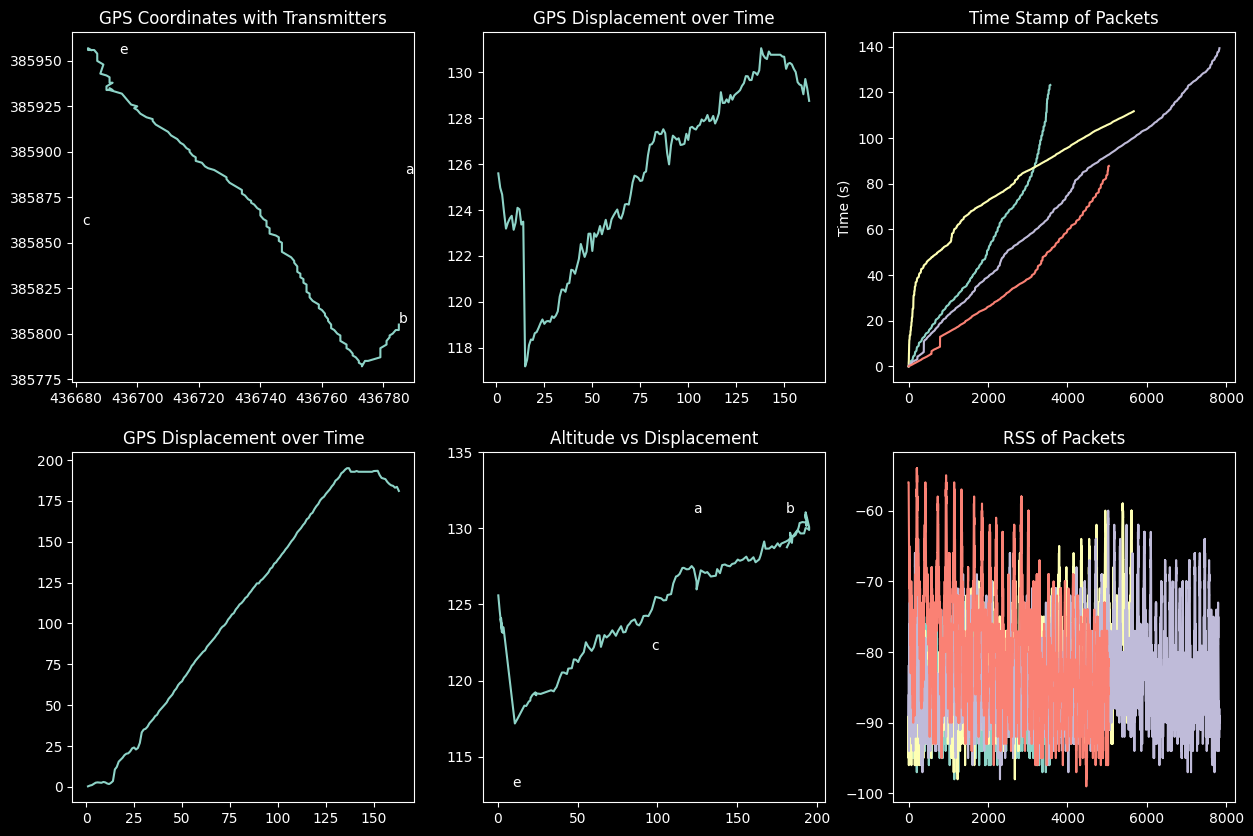

In [16]:
# plot gps coordinates and rss over time on a graph
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.title("GPS Coordinates with Transmitters")
plt.plot([getattr(obj, "easting") for obj in gps_data], [getattr(obj, "northing") for obj in gps_data])
for tx in (tx_a, tx_b, tx_c, tx_e):
    plt.annotate(tx.tx_id, tx.easting_northing())

plt.subplot(2, 3, 2)
plt.title("GPS Displacement over Time")
plt.plot([getattr(obj, "relative_time") for obj in gps_data], [getattr(obj, "altitude") for obj in gps_data])

plt.subplot(2, 3, 3)
plt.title("Time Stamp of Packets")
plt.plot([getattr(obj, "time") for obj in log_data_a])
plt.plot([getattr(obj, "time") for obj in log_data_b])
plt.plot([getattr(obj, "time") for obj in log_data_c])
plt.plot([getattr(obj, "time") for obj in log_data_e])
plt.ylabel("Time (s)")

plt.subplot(2, 3, 4)
plt.title("GPS Displacement over Time")
plt.plot([getattr(obj, "relative_time") for obj in gps_data], [getattr(obj, "displacement") for obj in gps_data])

plt.subplot(2, 3, 5)
plt.ylim(112, 135)
plt.title("Altitude vs Displacement")
plt.plot([getattr(obj, "displacement") for obj in gps_data], [getattr(obj, "altitude") for obj in gps_data])
for tx in (tx_a, tx_b, tx_c, tx_e):
    plt.annotate(tx.tx_id, (gps_data[0].dist_to_point(tx.northing, tx.easting), tx.altitude))
    print(gps_data[0].dist_to_point(tx.northing, tx.easting), tx.altitude)

plt.subplot(2, 3, 6)
plt.title("RSS of Packets")
plt.plot([getattr(obj, "rss") for obj in log_data_a])
plt.plot([getattr(obj, "rss") for obj in log_data_b])
plt.plot([getattr(obj, "rss") for obj in log_data_c])
plt.plot([getattr(obj, "rss") for obj in log_data_e])
plt.show()

### Transmitter E

RSS of received packets vs the modelled RSS. As shown by the graph, the model fits the data extremely well.

In [22]:
def plot_rss_vs_distance(gps_points :list, log_data :list):
    x_values = []
    y_values = []

    for j in range(0, len(gps_points) - 2):
        gps = gps_points[j]
        gps_next = gps_points[j + 1]

        logs = list(filter(lambda point: gps.relative_time <= point.time < gps_next.relative_time, log_data))

        x_values.extend(np.linspace(gps.displacement, gps_next.displacement, len(logs)))
        y_values.extend([getattr(obj, "rss") for obj in logs])

    plt.plot(x_values, y_values)
    plt.xlabel("Distance (m)")
    plt.ylabel("RSS (dBm)")

    return int(x_values[-1])

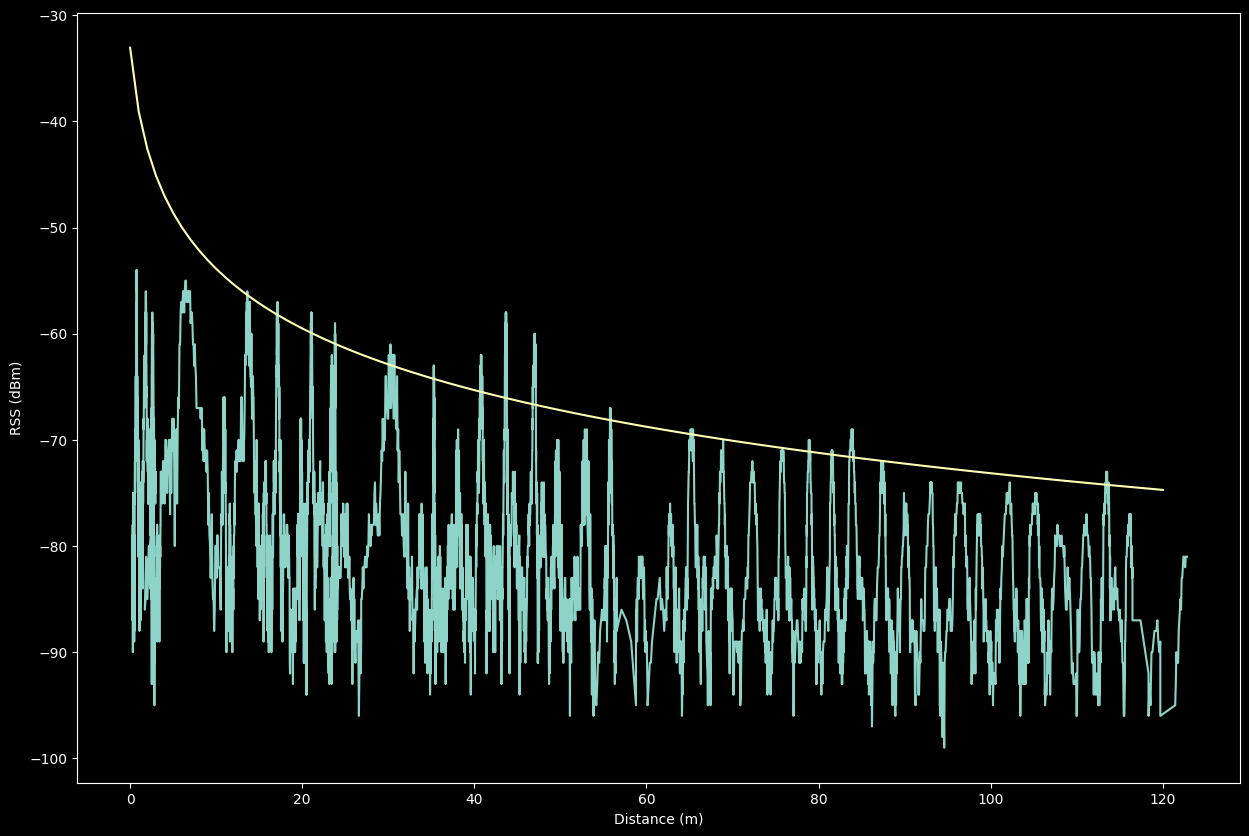

In [23]:
plt.figure(figsize=(15,10))
max_x_value = plot_rss_vs_distance(gps_data, log_data_e)

# plot FSPL estimates RSS
fspl_points = []

for x in range (1, max_x_value):
    fspl_points.append(-1 * signal_loss(x) + -8) # -7 is the transmitter power

plt.plot(fspl_points)
plt.show()

### Transmitter B

Actual vs modelled RSS of the packets received by the tag. While the graph appears to show the real RSS follows the model, it required lots of manual tuning to decide how many packets to cut off the start of the log. There are very few packets received from transmitter B in teh first 60 seconds, so altering how many are cut off dramatically effects the graph.

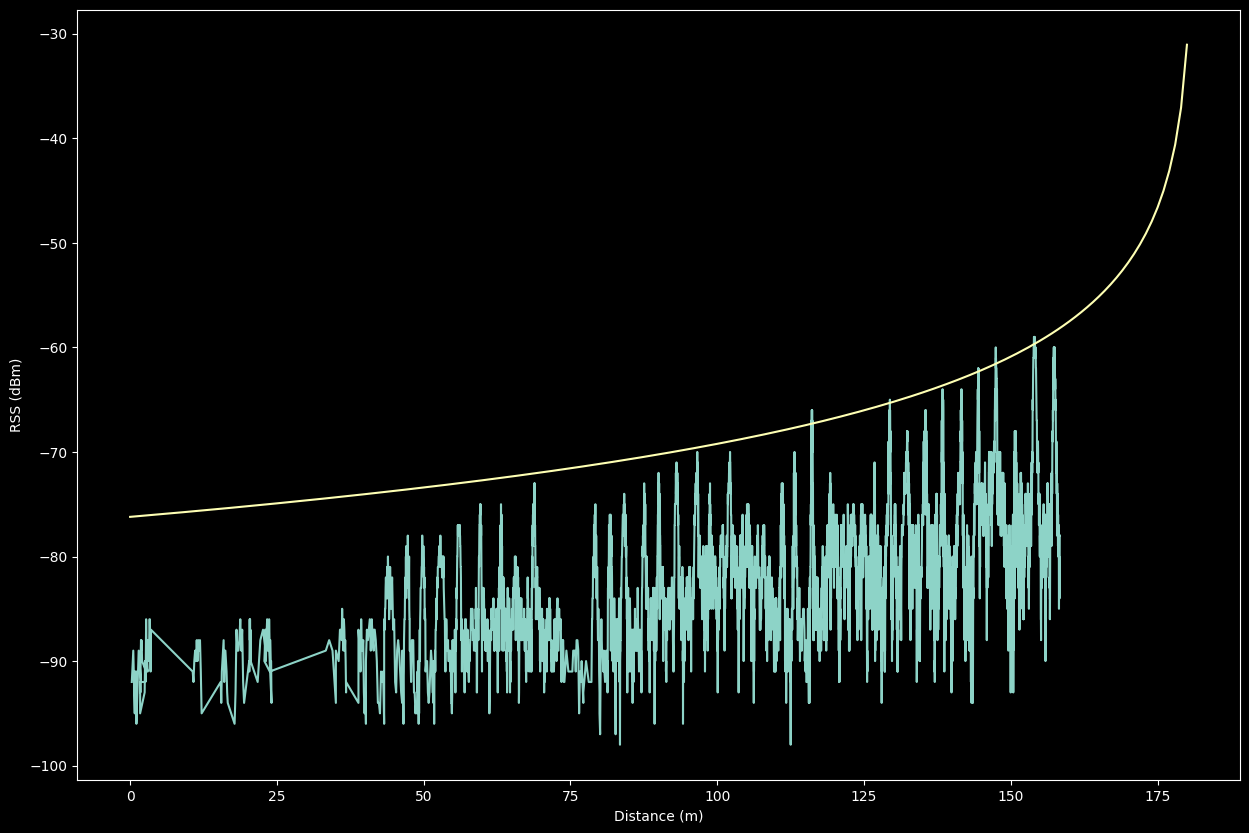

In [24]:
plt.figure(figsize=(15,10))
max_x_value = plot_rss_vs_distance(gps_data, log_data_b)

# plot FSPL estimates RSS
fspl_points = []
for x in range (int(gps_data[-1].displacement), 0, -1):
    fspl_points.append(-1 * signal_loss(x) + transmitter_power)

plt.plot(fspl_points)
plt.show()

### Transmitter C

Transmitter C is located to the side of the tag's path, so the tag moves towards and then away from the transmitter.

Without adjusting the packet range, the actual RSS bears no resemblance to the predicted value or form of the predicted RSS. This is very surprising, especially when it gets so much higher towards the end.

If you remove the last 2,800 packets, bringing the total down to ~5,000 just like the other transmitters, the actual RSS slightly resembles the pattern predicted by FSPL up until 100m. The actual values are still lower than expected. Maybe this is due to a person being inbetween the tag and the transmitter?

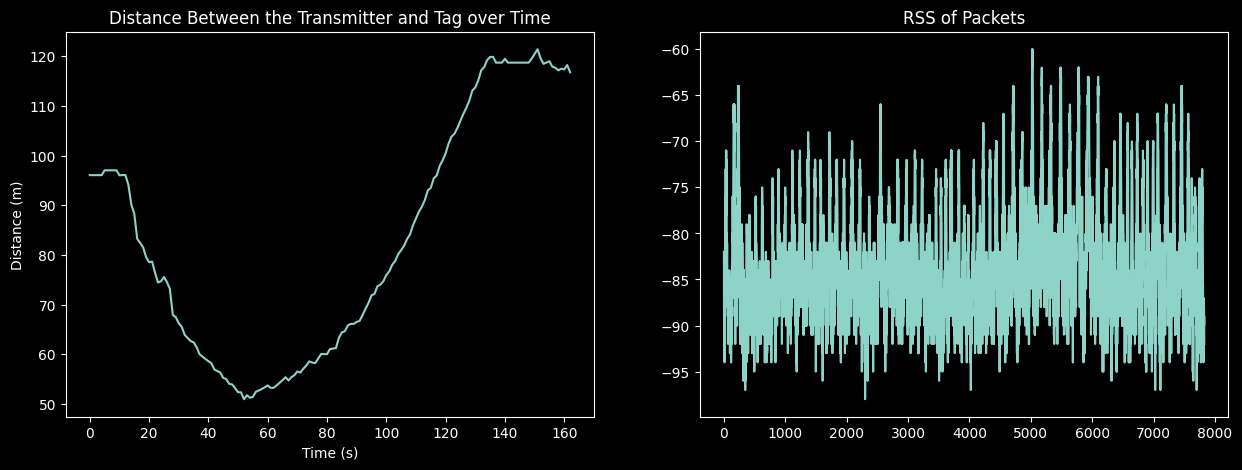

In [25]:
# calculate distance to gps device over time
dist_c_to_gps = []

for gps in gps_data:
    dist_c_to_gps.append(gps.dist_to_point(tx_c.northing, tx_c.easting))

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.plot(dist_c_to_gps)
plt.ylabel("Distance (m)")
plt.xlabel("Time (s)")
plt.title("Distance Between the Transmitter and Tag over Time")
plt.subplot(1, 2, 2)
plt.plot([getattr(obj, "rss") for obj in log_data_c])
plt.title("RSS of Packets")
plt.show()

Standardising angles and times (shifting by 0.00 degrees)
BlePacket.parse_log: transmitter: c, time range: 1814797.0 to 1907444.0 (92.647s total), num. packets: 5028


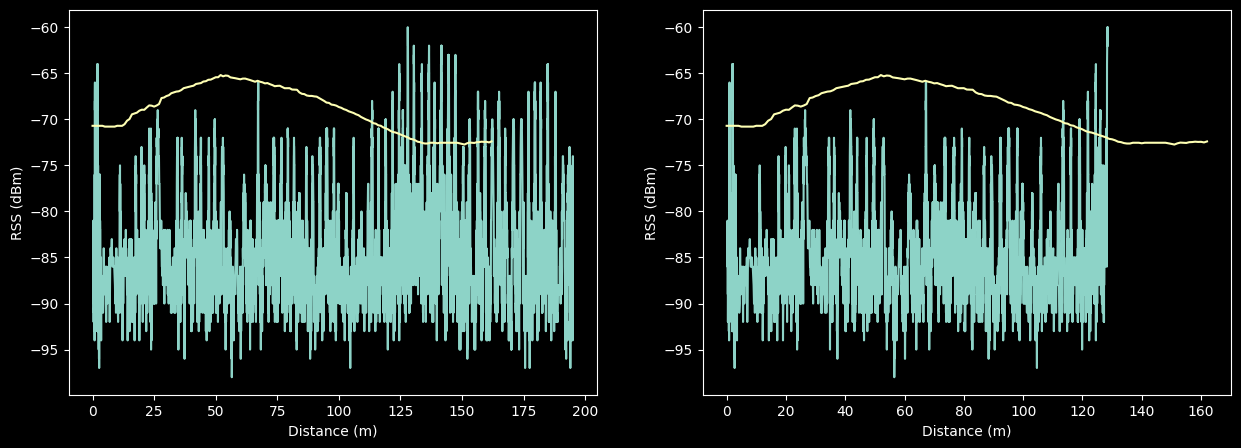

In [26]:
c_modelled_rss = []

for dist in dist_c_to_gps:
    c_modelled_rss.append(-1 * signal_loss(dist) + transmitter_power)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plot_rss_vs_distance(gps_data, log_data_c)
plt.plot(c_modelled_rss)

plt.subplot(1, 2, 2)
log_data_c_5000 = BlePacket.parse_log("/home/finley/Git/BLEanalysis/bluetooth_experiments/March 26 2025 Field Trial/straightpath5/straightpath5noperson.log", 'c', end=2800)
plot_rss_vs_distance(gps_data, log_data_c_5000)
plt.plot(c_modelled_rss)
plt.show()

### Transmitter A

Transmitter A is located on the Northern side of the path in a similar fashion to C's position.

While there are a few points at the start that have an RSS that's predicted by the model, that's it. The RSS decreases as the tag approaches the transmitter, which is surprising. It then continues to decrease. Decreasing the transmitter's (estimated) power output beyond -9 doesn't make the data fit the model any more.

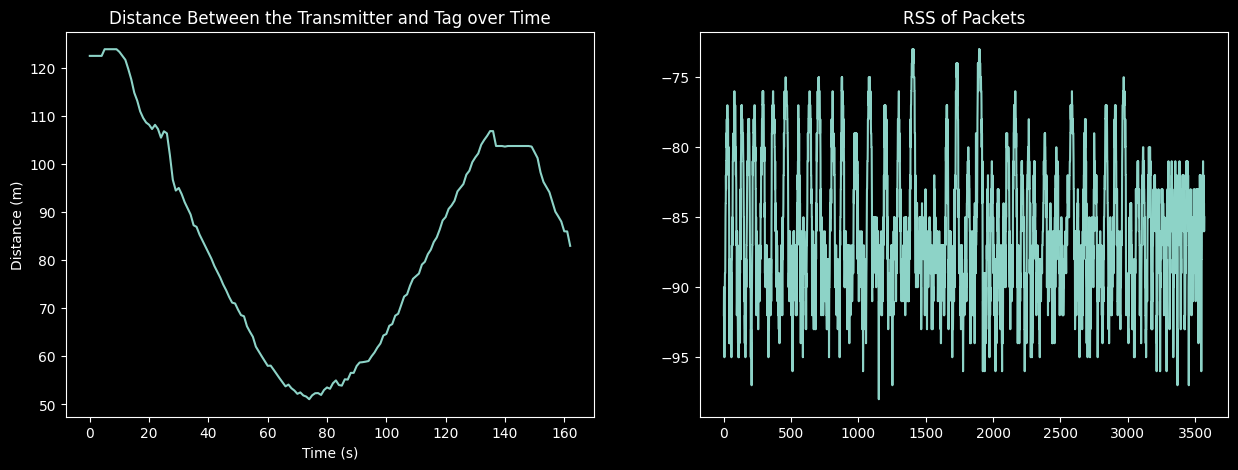

In [27]:
# calculate distance to gps device over time
dist_a_to_gps = []

for gps in gps_data:
    dist_a_to_gps.append(gps.dist_to_point(tx_a.northing, tx_a.easting))

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plt.plot(dist_a_to_gps)
plt.ylabel("Distance (m)")
plt.xlabel("Time (s)")
plt.title("Distance Between the Transmitter and Tag over Time")
plt.subplot(1, 2, 2)
plt.plot([getattr(obj, "rss") for obj in log_data_a])
plt.title("RSS of Packets")
plt.show()

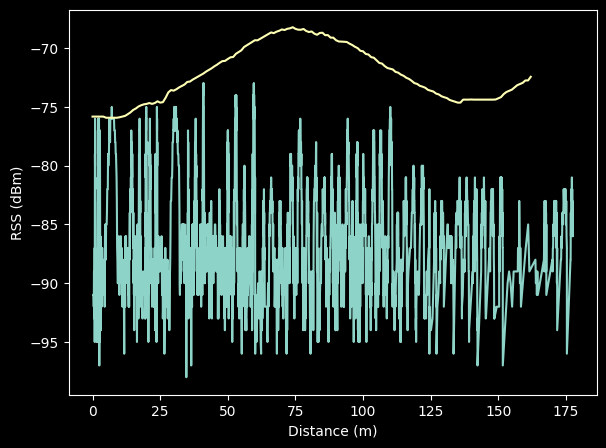

In [28]:
transmitter_a_power = -9
a_modelled_rss = []

for dist in dist_a_to_gps:
    a_modelled_rss.append(-1 * signal_loss(dist) + transmitter_a_power)

plt.figure(figsize=(15,5))
plt.subplot(1, 2, 1)
plot_rss_vs_distance(gps_data, log_data_a)
plt.plot(a_modelled_rss)